In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np 
# For reproducibility of random initializations
torch.manual_seed(42)

In [2]:
import torch
import torch.nn as nn


class Perceptron(nn.Module):

    def __init__(self, input_size: int):
        super().__init__()  # Simplified Python 3 super call
        self.linear = nn.Linear(input_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.sigmoid(self.linear(x))


# Usage example:
model = Perceptron(input_size=10)
sample_input = torch.randn(32, 10)  # Batch of 32 samples, 10 features each
output = model(sample_input)  # Output shape: (32, 1)


In [8]:
sample_input.size()

torch.Size([32, 10])

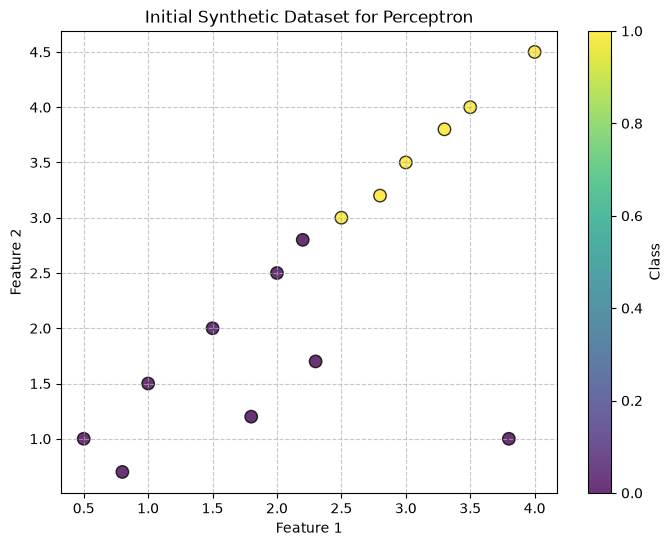

In [12]:
X = torch.tensor([
    [0.5, 1.0], [1.5, 2.0], [2.5, 3.0],
    [1.0, 1.5], [0.8, 0.7], [2.0, 2.5],
    [3.0, 3.5], [3.5, 4.0], [4.0, 4.5],
    [2.8, 3.2], [3.3, 3.8], [2.2, 2.8],
    [1.8, 1.2], [2.3, 1.7], [3.8, 1.0]
], dtype=torch.float32)

y = torch.tensor([
    0, 0, 1,
    0, 0, 0,
    1, 1, 1,
    1, 1, 0,
    0, 0, 0
], dtype=torch.float32).view(-1, 1) # Reshape y to (num_samples, 1)

# Visualize the initial dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='viridis', edgecolor='k', s=80, alpha=0.8)
plt.title('Initial Synthetic Dataset for Perceptron')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.colorbar(label='Class')
plt.show()

In statistics, the **logit** (logistic unit) or **log-odds** function is the quantile function associated with the standard logistic distribution. It has many uses in data analysis and machine learning, especially in data transformations.

Mathematically, the logit is the inverse of the standard logistic function $\sigma(x) = \frac{1}{1 + e^{-x}}$, so the logit is defined as:

$$\operatorname{logit}(p) = \sigma^{-1}(p) = \ln \left(\frac{p}{1 - p}\right) \quad \text{for } p \in (0, 1)$$

Because of this, the logit is also called the **log-odds** since it is equal to the logarithm of the odds $\frac{p}{1 - p}$, where $p$ is a probability. Thus, the logit is a type of function that maps probability values from $(0, 1)$ to real numbers in $(-\infty, +\infty)$, akin to the probit function.

In [19]:
### Forward pss

input_size = X.shape[1]
perceptron = Perceptron(input_size=input_size)
criterion = nn.BCEWithLogitsLoss() # Combines Sigmoid and BCE for stability
learning_rate = 0.1
optimizer = optim.SGD(perceptron.parameters(), lr=learning_rate)

num_epochs = 100
print("Starting Training Loop...")
for epoch in range(num_epochs):
    outputs = perceptron.linear(X) # Get raw logits
    print(f'epoch no={epoch}, outputs={outputs}')
    loss = criterion(outputs, y)
    print(f'loss: {loss}')

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f'optimizer: {optimizer}')
    
    current_weights = perceptron.linear.weight.data.numpy()
    current_bias = perceptron.linear.bias.data.item()
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, '
            f'Weights: {current_weights.flatten()}, Bias: {current_bias:.4f}')

print("\nTraining Complete!")

with torch.no_grad():
    final_outputs_logits = perceptron.linear(X)
    print(f'final_outputs_logits: {final_outputs_logits}')
    final_probabilities = torch.sigmoid(final_outputs_logits)
    print(f'final_probabilities: {final_probabilities}')
    predicted_classes = (final_probabilities >= 0.5).float()
    print(f'predicted_classes: {predicted_classes}')
    accuracy = (predicted_classes == y).float().mean().item()
    print(f"\nFinal Accuracy on Training Data: {accuracy:.4f}")


Starting Training Loop...
epoch no=0, outputs=tensor([[-0.5566],
        [-0.7854],
        [-1.0143],
        [-0.6710],
        [-0.5249],
        [-0.8998],
        [-1.1287],
        [-1.2431],
        [-1.3575],
        [-1.0662],
        [-1.1973],
        [-0.9623],
        [-0.6701],
        [-0.7845],
        [-0.7597]], grad_fn=<AddmmBackward0>)
loss: 0.8122047185897827
optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
Epoch [1/100], Loss: 0.8122, Weights: [ 0.00246196 -0.0851818 ], Bias: -0.3475
epoch no=1, outputs=tensor([[-0.4315],
        [-0.5142],
        [-0.5969],
        [-0.4728],
        [-0.4052],
        [-0.5556],
        [-0.6383],
        [-0.6796],
        [-0.7210],
        [-0.6132],
        [-0.6631],
        [-0.5806],
        [-0.4453],
        [-0.4867],
        [-0.4234]], grad_fn=<AddmmBackward0>)
loss

percepton:Linear(in_features=2, out_features=1, bias=True)


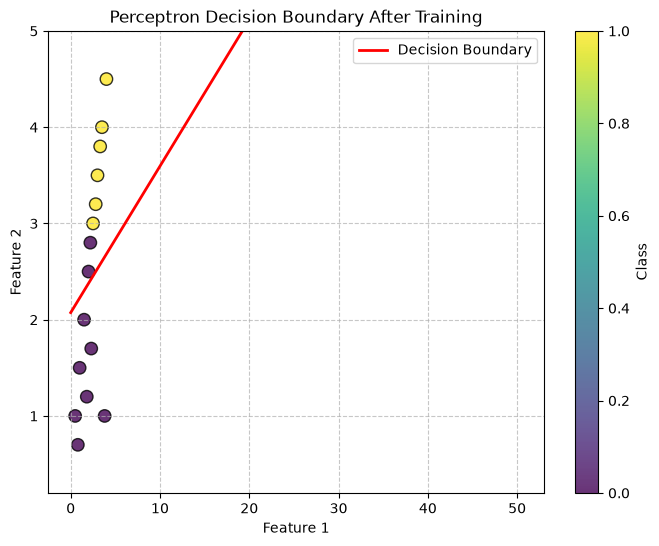


Testing with new data points:
New Input: [10.   3.5] -> Predicted Class: 0 (Probability: 0.4829)
New Input: [31.5 14.2] -> Predicted Class: 1 (Probability: 0.9947)
New Input: [25. 22.] -> Predicted Class: 1 (Probability: 1.0000)


In [24]:
# --- 6. Visualize the Decision Boundary and Data Points ---
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='viridis', edgecolor='k', s=80, alpha=0.8)
plt.title('Perceptron Decision Boundary After Training')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot the decision boundary (w1*x1 + w2*x2 + b = 0)
# Rearranging: x2 = (-w1*x1 - b) / w2
w1, w2 = perceptron.linear.weight.data.numpy().flatten()
print(f'percepton:{perceptron.linear}')
b = perceptron.linear.bias.data.item()

# Create a range of x1 values for the plot
x1_min, x1_max = X[:, 0].min().item(), 50
x1_plot = np.linspace(x1_min - 0.5, x1_max + 0.5, 100) # Extend range slightly

# Calculate corresponding x2 values for the decision boundary line
if abs(w2) > 1e-6: # Avoid division by zero if w2 is near zero
    x2_plot = (-w1 * x1_plot - b) / w2
    plt.plot(x1_plot, x2_plot, color='red', linestyle='-', linewidth=2, label='Decision Boundary')
    # Adjust y-limits to ensure the boundary line is fully visible and the plot looks good
    plt.ylim(X[:, 1].min().item() - 0.5, X[:, 1].max().item() + 0.5)
else:
    # If w2 is near zero, the boundary is essentially vertical (x1 = -b/w1)
    if abs(w1) > 1e-6:
        plt.axvline(x=-b/w1, color='red', linestyle='-', linewidth=2, label='Decision Boundary')
    else:
        # If both w1 and w2 are near zero, the boundary is undefined or the model hasn't learned
        pass

plt.legend()
plt.colorbar(label='Class')
plt.show()

# --- 7. Test with a few new data points ---
print("\nTesting with new data points:")
new_data = torch.tensor([
    [10.0, 3.5],
    [31.5, 14.2],
    [25.0, 22.0]
], dtype=torch.float32)

with torch.no_grad():
    new_outputs_logits = perceptron.linear(new_data)
    new_probabilities = torch.sigmoid(new_outputs_logits)
    new_predictions = (new_probabilities >= 0.5).float()

    for i in range(new_data.size(0)):
        print(f"New Input: {new_data[i].numpy()} -> Predicted Class: {int(new_predictions[i].item())} "
              f"(Probability: {new_probabilities[i].item():.4f})")


torch.Size([15, 2])